In [37]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import contextily as ctx # Nhập thư viện bản đồ
import geopandas as gpd
from shapely.geometry import Point
from sklearn.decomposition import PCA

In [38]:
df = pd.read_csv("train.csv")

In [39]:
pd.set_option('display.float_format', lambda x: '%.5f' % x)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   id                  1458644 non-null  str    
 1   vendor_id           1458644 non-null  int64  
 2   pickup_datetime     1458644 non-null  str    
 3   dropoff_datetime    1458644 non-null  str    
 4   passenger_count     1458644 non-null  int64  
 5   pickup_longitude    1458644 non-null  float64
 6   pickup_latitude     1458644 non-null  float64
 7   dropoff_longitude   1458644 non-null  float64
 8   dropoff_latitude    1458644 non-null  float64
 9   store_and_fwd_flag  1458644 non-null  str    
 10  trip_duration       1458644 non-null  int64  
dtypes: float64(4), int64(3), str(4)
memory usage: 122.4 MB


no value is null or na

In [40]:
df.describe()

,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration
count,1458644.00000,1458644.00000,1458644.00000,1458644.00000,1458644.00000,1458644.00000,1458644.00000
mean,1.53495,1.66453,-73.97349,40.75092,-73.97342,40.75180,959.49227
std,0.49878,1.31424,0.07090,0.03288,0.07064,0.03589,5237.43172
min,1.00000,0.00000,-121.93334,34.35970,-121.93330,32.18114,1.00000
25%,1.00000,1.00000,-73.99187,40.73735,-73.99133,40.73588,397.00000
50%,2.00000,1.00000,-73.98174,40.75410,-73.97975,40.75452,662.00000
75%,2.00000,2.00000,-73.96733,40.76836,-73.96301,40.76981,1075.00000
max,2.00000,9.00000,-61.33553,51.88108,-61.33553,43.92103,3526282.00000


các điều có thể chú ý:\
trip_duration: có outlier dài đến 1k -> 300k mấy, có chuyến 1 giây. mean = 959 nhưng std đến 5000.

Kinh độ (Longitude) Min là -121.93: Tọa độ này nằm ở tận... bờ Tây nước Mỹ (khu vực California/Oregon).

Kinh độ (Longitude) Max là -61.33: Tọa độ này nằm chơ vơ ngoài biển Đại Tây Dương.

passenger giá trị Min là 0, max là 9 (có thể)

no missing value

đi tìm các khoản percentile

In [41]:

# Xem phân vị thứ 99 và 99.9 của thời gian chuyến đi
print(np.percentile(df['trip_duration'], 1)) 
print(np.percentile(df['trip_duration'], 99)) 
print(np.percentile(df['trip_duration'], 99.9))

87.0
3440.0
85128.35700000008


In [42]:
print("how much percentage is above 5400",(df['trip_duration'] > 5400).sum()/len(df)*100)
print("how much percentage is below 90",(df['trip_duration'] < 90).sum()/len(df))

how much percentage is above 5400 0.21232048395633205
how much percentage is below 90 0.0105920293094134


In [43]:
# Count the occurrences of each passenger count
passenger_distribution = df['passenger_count'].value_counts()

print(passenger_distribution)

passenger_count
1    1033540
2     210318
5      78088
3      59896
6      48333
4      28404
0         60
7          3
9          1
8          1
Name: count, dtype: int64


In [44]:
# Bỏ các outlier (amputing)
df_clean = df[(df['trip_duration'] > 90) & (df['trip_duration'] < 5400)].copy()

# Lọc tọa độ: Giới hạn trong khu vực thành phố New York (Bounding Box)
lon_min, lon_max = -74.05, -73.75
lat_min, lat_max = 40.60, 40.85
lon_ny = (lon_min, lon_max)
lat_ny = (lat_min, lat_max)


df_clean = df[
    (df['trip_duration'] > 90) & (df['trip_duration'] < 5400) & # Thời gian
    (df['passenger_count'] > 0) & (df['passenger_count'] <= 6) & # Số khách
    (df['pickup_longitude'].between(lon_min, lon_max)) &         # Khung Bounding Box (Đón)
    (df['pickup_latitude'].between(lat_min, lat_max)) &
    (df['dropoff_longitude'].between(lon_min, lon_max)) &        # Khung Bounding Box (Trả)
    (df['dropoff_latitude'].between(lat_min, lat_max))
].copy()

In [45]:
# 1. Tải bản đồ
geojson_file = "new-york-city-boroughs.geojson" 
nyc_boroughs = gpd.read_file(geojson_file)

# 2. Tạo GeoDataFrame từ dữ liệu đã được gọt dũa ở Bước 1
geometry_pickup = [Point(xy) for xy in zip(df_clean['pickup_longitude'], df_clean['pickup_latitude'])]
gdf_taxi = gpd.GeoDataFrame(df_clean, geometry=geometry_pickup)
gdf_taxi.set_crs(epsg=4326, inplace=True)

# 3. Ép điểm đón vào đất liền
gdf_land_only = gpd.sjoin(gdf_taxi, nyc_boroughs, how="inner", predicate="intersects")

# 4. TRẢ VỀ KẾT QUẢ CUỐI CÙNG
# Chuyển ngược lại thành DataFrame bình thường, chỉ giữ lại các cột gốc của df_clean
# (Loại bỏ các cột rác như geometry, index_right... do GeoPandas sinh ra)
df_clean = pd.DataFrame(gdf_land_only)[df.columns]

print(f"Hoàn tất làm sạch! Dữ liệu sẵn sàng cho huấn luyện: {len(df_clean)} chuyến xe.")

Hoàn tất làm sạch! Dữ liệu sẵn sàng cho huấn luyện: 1424337 chuyến xe.


In [46]:
def calculate_distances(df):
    # Chuyển đổi tọa độ từ độ (degrees) sang radian
    lat1, lng1 = np.radians(df['pickup_latitude']), np.radians(df['pickup_longitude'])
    lat2, lng2 = np.radians(df['dropoff_latitude']), np.radians(df['dropoff_longitude'])
    
    # Bán kính Trái Đất (km)
    R = 6371.0 
    
    # 2. TÍNH KHOẢNG CÁCH MANHATTAN
    dlat = lat2 - lat1
    dlng = lng2 - lng1
    # Tính thành phần dọc (Bắc - Nam) bằng cách giữ nguyên kinh độ (lng1)
    a_lat = np.sin(dlat / 2.0)**2
    c_lat = 2 * np.arcsin(np.sqrt(a_lat))
    dist_lat = R * c_lat
    
    # Tính thành phần ngang (Đông - Tây) bằng cách giữ nguyên vĩ độ (lat2)
    a_lng = np.cos(lat1) * np.cos(lat1) * np.sin(dlng / 2.0)**2
    c_lng = 2 * np.arcsin(np.sqrt(a_lng))
    dist_lng = R * c_lng
    
    df['dist_manhattan_km'] = dist_lat + dist_lng
    
    return df


In [47]:
def add_direction_feature(df):
    """Tính góc di chuyển (Bearing) giữa 2 tọa độ"""
    # Đổi sang radian để tính toán lượng giác
    lat1 = np.radians(df['pickup_latitude'])
    lon1 = np.radians(df['pickup_longitude'])
    lat2 = np.radians(df['dropoff_latitude'])
    lon2 = np.radians(df['dropoff_longitude'])
    
    dlon = lon2 - lon1
    
    # Công thức tính phương vị (Bearing)
    x = np.sin(dlon) * np.cos(lat2)
    y = np.cos(lat1) * np.sin(lat2) - (np.sin(lat1) * np.cos(lat2) * np.cos(dlon))
    
    initial_bearing = np.arctan2(x, y)
    
    # Đổi lại sang độ (Degrees) và chuẩn hóa về thang 0-360 độ
    initial_bearing = np.degrees(initial_bearing)
    df['direction_angle'] = (initial_bearing + 360) % 360
    
    return df


In [48]:
def add_heuristic_speed(df_train, df_test):
    """Tính tốc độ trung bình theo từng khung giờ từ tập Train"""
    
    # 1. Tính tốc độ thực tế của từng cuốc xe trong tập Train (km/h)
    # Tốc độ = Quãng đường / (Thời gian bằng giây / 3600)
    df_train['trip_speed_kmh'] = df_train['dist_manhattan_km'] / (df_train['trip_duration'] / 3600)
    
    # Lọc bỏ các xe đứng im hoặc chạy nhanh vô lý (nhiễu GPS)
    valid_speed_mask = (df_train['trip_speed_kmh'] > 1) & (df_train['trip_speed_kmh'] < 100)
    
    # 2. Tạo bảng tra cứu: Tính tốc độ Trung vị (Median) theo từng giờ
    # Dùng Median thay vì Mean để không bị ảnh hưởng bởi outlier
    hourly_speed = df_train[valid_speed_mask].groupby('pickup_hour')['trip_speed_kmh'].median().reset_index()
    hourly_speed.rename(columns={'trip_speed_kmh': 'median_hourly_speed'}, inplace=True)
    
    # 3. Gắn cột tốc độ này vào cả Train và Test
    df_train = df_train.merge(hourly_speed, on='pickup_hour', how='left')
    df_test = df_test.merge(hourly_speed, on='pickup_hour', how='left')
    
    # Xóa cột tốc độ gốc của từng cuốc xe (để tránh Data Leakage khi train XGBoost)
    df_train.drop(columns=['trip_speed_kmh'], inplace=True)
    
    return df_train, df_test

In [49]:
def manual_rotate(df):
    theta = np.radians(-29) # Xoay ngược lại 29 độ để Manhattan thẳng đứng
    
    # Xoay tọa độ Pickup
    df['pickup_rot_lat'] = df['pickup_latitude'] * np.cos(theta) - df['pickup_longitude'] * np.sin(theta)
    df['pickup_rot_lon'] = df['pickup_latitude'] * np.sin(theta) + df['pickup_longitude'] * np.cos(theta)
    
    # Xoay tọa độ Dropoff
    df['dropoff_rot_lat'] = df['dropoff_latitude'] * np.cos(theta) - df['dropoff_longitude'] * np.sin(theta)
    df['dropoff_rot_lon'] = df['dropoff_latitude'] * np.sin(theta) + df['dropoff_longitude'] * np.cos(theta)
    
    return df

"Vì thuật toán XGBoost thực hiện phân chia dữ liệu dựa trên các nhát cắt trực giao (orthogonal splits), việc xoay tọa độ để khớp với lưới đường phố Manhattan (nghiêng ~29 độ) giúp mô hình giảm đáng kể độ phức tạp của các cây quyết định, từ đó tăng độ chính xác dự báo (R2) và giảm hiện tượng Overfitting."

In [50]:
# Áp dụng hàm vào dataset 

df_clean = manual_rotate(df_clean)
df_clean = calculate_distances(df_clean)
df_clean['pickup_datetime'] = pd.to_datetime(df_clean['pickup_datetime'])
df_clean['pickup_hour'] = df_clean['pickup_datetime'].dt.hour
df_clean['log_trip_duration'] = np.log10(df_clean['trip_duration'])
df_clean = add_direction_feature(df_clean)


df_test = pd.read_csv("test.csv")
df_test = manual_rotate(df_test)
df_test = calculate_distances(df_test)
df_test = add_direction_feature(df_test)
df_test['pickup_datetime'] = pd.to_datetime(df_test['pickup_datetime'])
df_test['pickup_hour'] = df_test['pickup_datetime'].dt.hour

df_clean, df_test = add_heuristic_speed(df_clean, df_test)
df_clean.to_csv('data_clean.csv', index=False) 
df_test.to_csv('test_transform.csv', index=False)

In [51]:
df_clean.describe()

,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration,pickup_rot_lat,pickup_rot_lon,dropoff_rot_lat,dropoff_rot_lon,dist_manhattan_km,pickup_hour,log_trip_duration,direction_angle,median_hourly_speed
count,1424337.00000,1424337,1424337.00000,1424337.00000,1424337.00000,1424337.00000,1424337.00000,1424337.00000,1424337.00000,1424337.00000,1424337.00000,1424337.00000,1424337.00000,1424337.00000,1424337.00000,1424337.00000,1424337.00000
mean,1.53501,2016-04-01 09:16:53.556428,1.66567,-73.97393,40.75101,-73.97378,40.75141,831.86601,-0.22164,-84.45554,-0.22121,-84.45560,4.31638,13.62605,2.81350,153.93419,16.53722
min,1.00000,2016-01-01 00:00:17,1.00000,-74.04138,40.60068,-74.04999,40.60004,91.00000,-0.37301,-84.48618,-0.37768,-84.56323,0.00000,0.00000,1.95904,0.00000,13.75658
25%,1.00000,2016-02-17 15:47:29,1.00000,-73.99191,40.73743,-73.99133,40.73605,402.00000,-0.24141,-84.47092,-0.24217,-84.47059,1.59212,9.00000,2.60423,45.33085,14.08842
50%,2.00000,2016-04-01 15:42:00,1.00000,-73.98181,40.75406,-73.97991,40.75443,662.00000,-0.22217,-84.46214,-0.22180,-84.46137,2.69027,14.00000,2.82086,169.33666,14.68535
75%,2.00000,2016-05-15 02:29:24,2.00000,-73.96766,40.76828,-73.96361,40.76945,1065.00000,-0.20410,-84.45439,-0.20048,-84.45293,4.92070,19.00000,3.02735,224.26996,18.45556
max,2.00000,2016-06-30 23:59:39,6.00000,-73.75282,40.85000,-73.75000,40.85000,5399.00000,-0.05101,-84.20380,-0.04443,-84.19160,38.23659,23.00000,3.73231,359.99347,28.50467
std,0.49877,NaN,1.31506,0.03702,0.02741,0.03227,0.03014,630.62872,0.02804,0.03654,0.03186,0.03058,4.91825,6.38114,0.30812,103.95151,3.13283


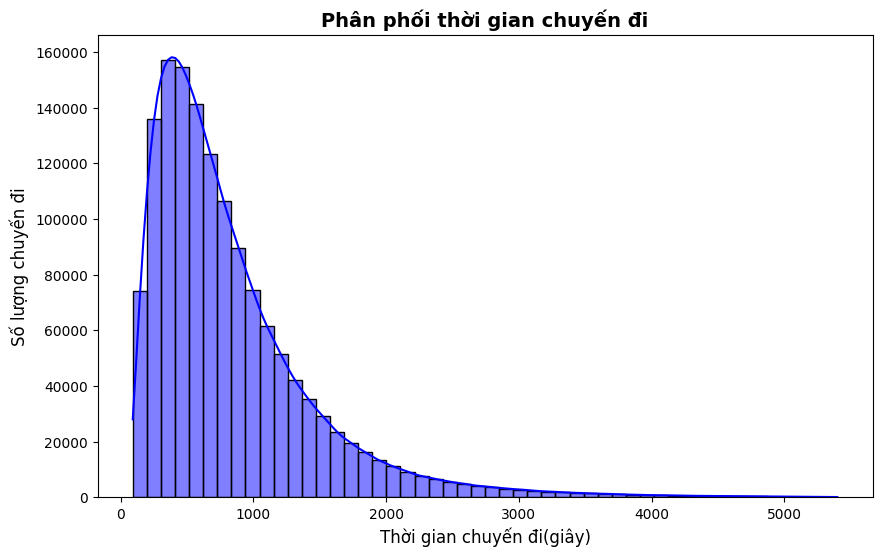

In [52]:
# 1. Khởi tạo khung hình với kích thước vừa vặn cho 1 biểu đồ
plt.figure(figsize=(10, 6))

# 2. Vẽ biểu đồ (Đã thêm np.log10 để chuẩn với thang Log10)
sns.histplot((df_clean['trip_duration']), bins=50, kde=True, color='blue')

# 3. Thiết lập tiêu đề và nhãn các trục
plt.title('Phân phối thời gian chuyến đi', fontsize=14, fontweight='bold')
plt.xlabel('Thời gian chuyến đi(giây)', fontsize=12)
plt.ylabel('Số lượng chuyến đi', fontsize=12)

# 4. Hiển thị biểu đồ
plt.show()

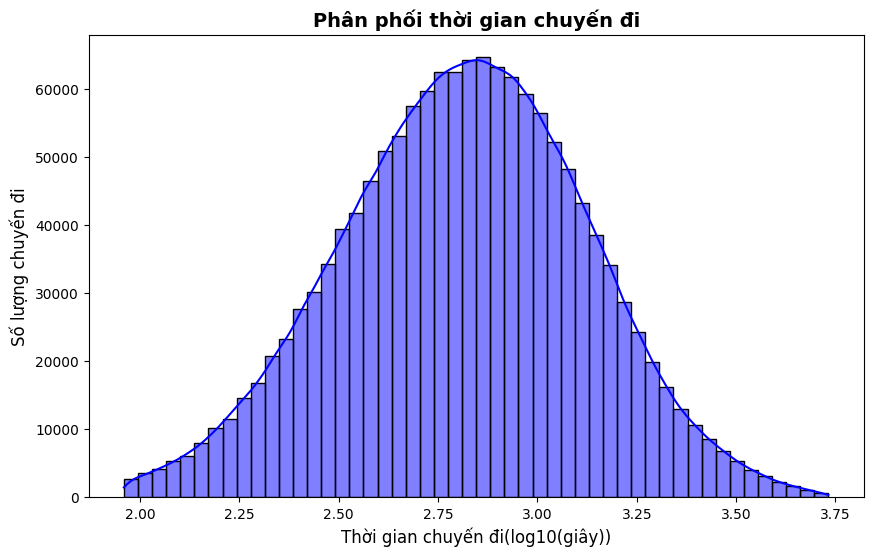

In [53]:
# 1. Khởi tạo khung hình với kích thước vừa vặn cho 1 biểu đồ
plt.figure(figsize=(10, 6))

# 2. Vẽ biểu đồ (Đã thêm np.log10 để chuẩn với thang Log10)
sns.histplot(np.log10(df_clean['trip_duration']), bins=50, kde=True, color='blue')

# 3. Thiết lập tiêu đề và nhãn các trục
plt.title('Phân phối thời gian chuyến đi', fontsize=14, fontweight='bold')
plt.xlabel('Thời gian chuyến đi(log10(giây))', fontsize=12)
plt.ylabel('Số lượng chuyến đi', fontsize=12)

# 4. Hiển thị biểu đồ
plt.show()

1. Tại sao biểu đồ gốc (Không dùng Log) lại có đuôi dài (Lệch phải)?Nhìn vào Biểu đồ 1, bạn thấy dữ liệu tụ tập rất đông ở bên trái và kéo một cái "đuôi" rất dài về bên phải (Right-skewed). Điều này xảy ra do 2 đặc tính của thời gian di chuyển:Bị chặn ở số 0 (Zero-bounded): Một chuyến taxi không bao giờ có thời gian âm. Thời gian ngắn nhất chỉ có thể là vài giây hoặc 1 phút. Do đó, dữ liệu không thể tràn sang phía bên trái số 0.Không bị chặn ở số dương: Mặc dù phần lớn các chuyến đi ở New York chỉ kéo dài từ 5 - 15 phút (300 - 900 giây), nhưng thỉnh thoảng vẫn có những chuyến đi cực dài do kẹt xe nghiêm trọng, hoặc khách đi ra ngoại ô (kéo dài 3000, 4000 thậm chí 5000 giây). Những chuyến đi hiếm hoi này kéo giãn trục ngang ra tít mù tắp, tạo thành cái đuôi dài và ép toàn bộ các chuyến đi thông thường thành một cột cao vút ở bên trái.2. Tại sao hàm Log10 lại "nắn" nó thành hình chuông?Hàm Logarit cơ số 10 (log10) hoạt động như một cỗ máy "nén không gian" không đồng đều. Nó nén các con số khổng lồ lại rất mạnh, nhưng ít tác động đến các con số nhỏ.Hãy xem thử một ví dụ toán học thực tế trên trục X của bạn:Một chuyến đi 100 giây (khoảng 1.5 phút) -> log10(100) = 2.0Một chuyến đi 1.000 giây (khoảng 16 phút) -> log10(1000) = 3.0Một chuyến đi 10.000 giây (khoảng 2.7 tiếng) -> log10(10000) = 4.0Sự kỳ diệu nằm ở đây: Trong đời thực (Biểu đồ 1), khoảng cách giữa 100 giây và 1.000 giây chỉ là 900 đơn vị. Nhưng khoảng cách từ 1.000 giây đến 10.000 giây lên tới 9.000 đơn vị. Chênh lệch cực lớn này tạo ra cái đuôi dài.Nhưng sau khi dùng log10 (Biểu đồ 2), khoảng cách từ 2.0 lên 3.0 là 1 đơn vị, và từ 3.0 lên 4.0 cũng chỉ là 1 đơn vị!Hàm log đã "cầm" cái đuôi dài tít tắp kia và kéo giật nó thu gọn lại, đồng thời dàn trải phần đỉnh nhọn ở bên trái ra. Kết quả là nó tiết lộ ra một hình dáng đối xứng tuyệt đẹp: Hình chuông (Phân phối chuẩn - Normal Distribution).3. Ý nghĩa đối với dự án của nhóm (Dành cho Anh Khoa ở Phần 3)Việc biến đổi dữ liệu thành hình chuông không chỉ để nhìn cho đẹp, mà nó là "vũ khí bí mật" khi huấn luyện mô hình Machine Learning.Các thuật toán (đặc biệt là Linear Regression hoặc Neural Networks) hoạt động hiệu quả và chính xác nhất khi biến mục tiêu (target variable) có phân phối chuẩn.Nếu bạn để nguyên dữ liệu gốc (Biểu đồ 1) đưa vào học, mô hình sẽ bị "hoảng loạn" và dự đoán sai lệch vì nó cố gắng học theo các giá trị ngoại lai ở cái đuôi dài kia.Bằng cách chuyển trip_duration sang dạng log trước khi huấn luyện mô hình, mô hình sẽ học nhanh hơn và sai số (RMSE) sẽ giảm đi đáng kể. (Lưu ý: Sau khi mô hình dự đoán ra kết quả dạng log, bạn chỉ cần dùng hàm mũ $10^x$ để đảo ngược lại thành số giây thực tế là xong).

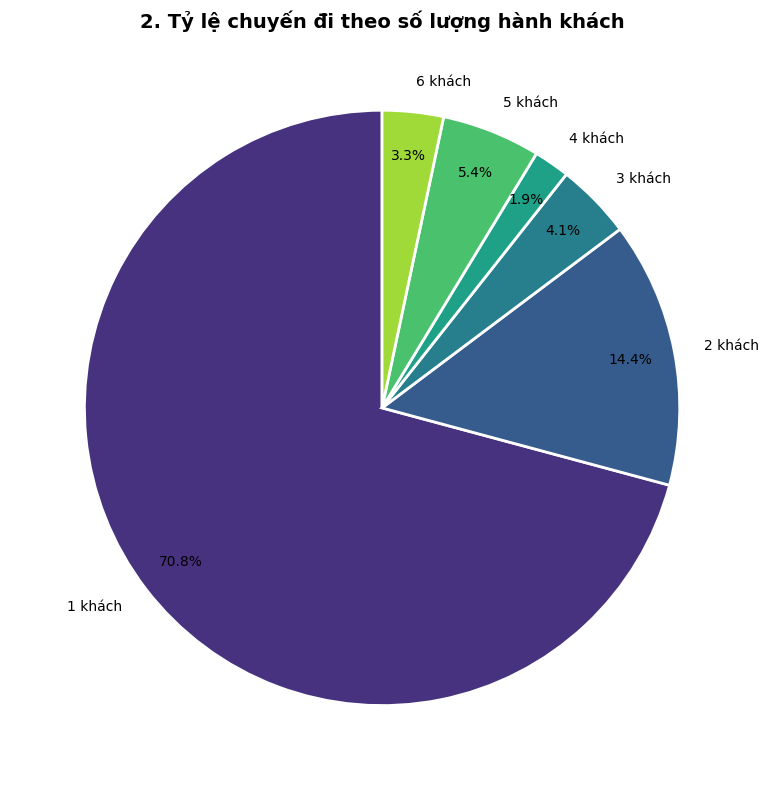

In [54]:
# 1. Tính tổng số chuyến đi theo từng lượng hành khách và sắp xếp theo thứ tự (1, 2, 3...)
passenger_counts = df_clean['passenger_count'].value_counts().sort_index()

# 2. Khởi tạo khung hình (Nên để kích thước vuông 8x8 cho biểu đồ tròn)
plt.figure(figsize=(8, 8))

# Lấy dải màu 'viridis' quen thuộc của Seaborn
colors = sns.color_palette('viridis', len(passenger_counts))

# 3. Vẽ biểu đồ tròn (Pie Chart)
plt.pie(passenger_counts.values, 
        labels=[f'{int(p)} khách' for p in passenger_counts.index], # Tạo nhãn: "1 khách", "2 khách"...
        autopct='%1.1f%%',       # Hiển thị phần trăm với 1 chữ số thập phân
        startangle=90,           # Bắt đầu vẽ từ góc 12 giờ
        colors=colors,
        pctdistance=0.85,        # Đẩy chữ số % ra xa tâm một chút cho dễ nhìn
        wedgeprops={'edgecolor': 'white', 'linewidth': 2}) # Tạo đường viền trắng giữa các mảnh

plt.title('2. Tỷ lệ chuyến đi theo số lượng hành khách', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

C:\Users\hjiis\AppData\Local\Temp\ipykernel_496\1258002228.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='passenger_count', y='trip_duration', data=df_clean, palette='Set2', showfliers=False)


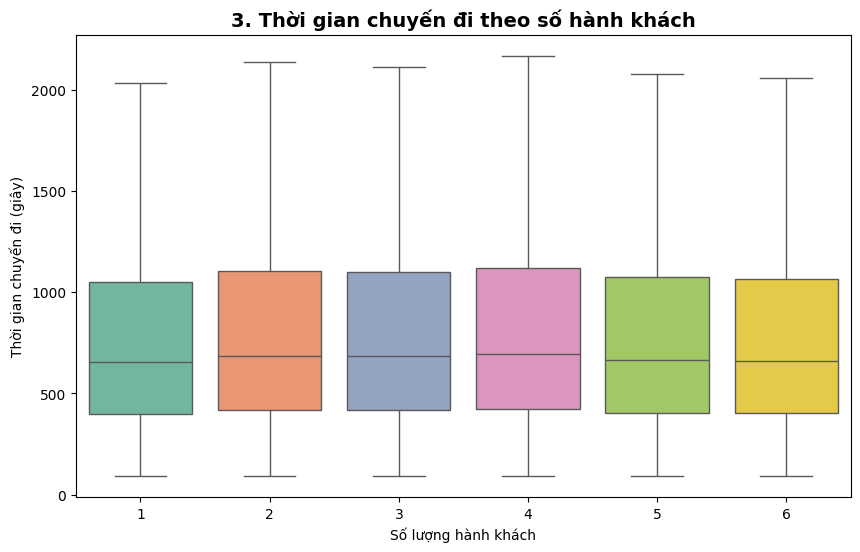

In [55]:
# --- Biểu đồ 3: So sánh Thời gian theo Số lượng Hành khách (Boxplot) ---
plt.figure(figsize=(10, 6))

sns.boxplot(x='passenger_count', y='trip_duration', data=df_clean, palette='Set2', showfliers=False)

plt.title('3. Thời gian chuyến đi theo số hành khách', fontsize=14, fontweight='bold')
plt.xlabel('Số lượng hành khách')
plt.ylabel('Thời gian chuyến đi (giây)')

plt.show()

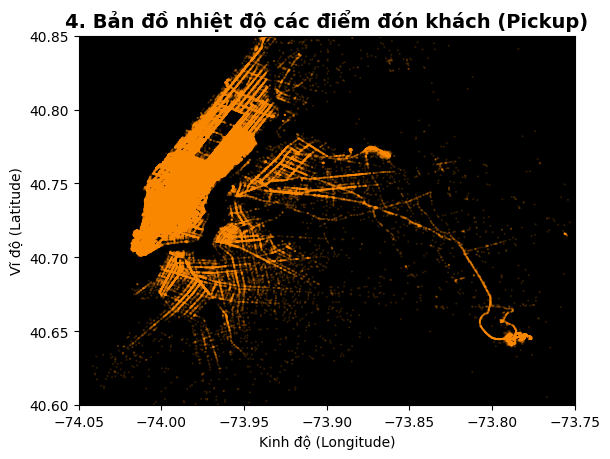

In [56]:
ax = sns.scatterplot(x='pickup_longitude', y='pickup_latitude', data=df_clean, 
                     s=2, alpha=0.2, color='darkorange', edgecolor='none')

plt.title('4. Bản đồ nhiệt độ các điểm đón khách (Pickup)', fontsize=14, fontweight='bold')
plt.xlabel('Kinh độ (Longitude)')
plt.ylabel('Vĩ độ (Latitude)')
ax.set_facecolor('black') # Nền đen giúp điểm sáng màu cam nổi bật, giống bản đồ đêm
ax.set_xlim(lon_ny)
ax.set_ylim(lat_ny)


plt.show()

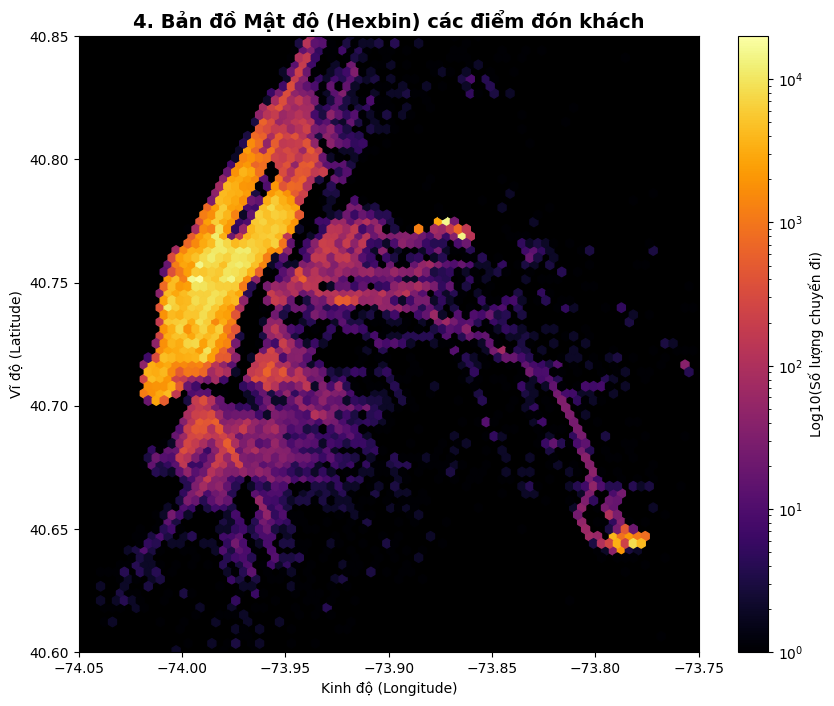

In [57]:
plt.figure(figsize=(10, 8))

# Sử dụng plt.hexbin thay vì scatter
hb = plt.hexbin(df_clean['pickup_longitude'], df_clean['pickup_latitude'], 
                gridsize=75, cmap='inferno', bins='log', mincnt=1)

# Thêm thanh chú thích màu sắc bên cạnh
cb = plt.colorbar(hb, label='Log10(Số lượng chuyến đi)')

plt.title('4. Bản đồ Mật độ (Hexbin) các điểm đón khách', fontsize=14, fontweight='bold')
plt.xlabel('Kinh độ (Longitude)')
plt.ylabel('Vĩ độ (Latitude)')

# SỬA Ở ĐÂY: Dùng plt.xlim và plt.ylim thay vì hb.set_xlim
plt.xlim(lon_ny)
plt.ylim(lat_ny)

# Đổi nền thành đen để các điểm màu nổi bật hơn
plt.gca().set_facecolor('black')

plt.show()

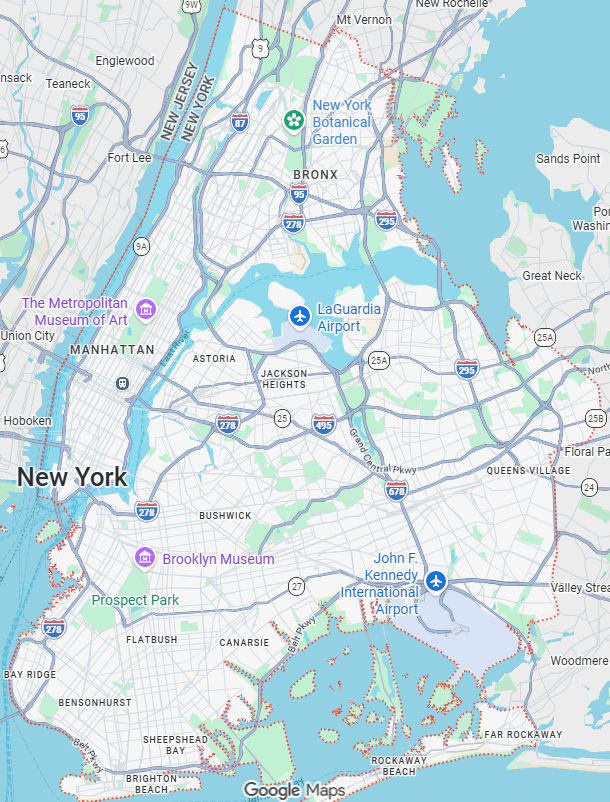

hai điểm nóng ngoài manhattan là 2 sân bay

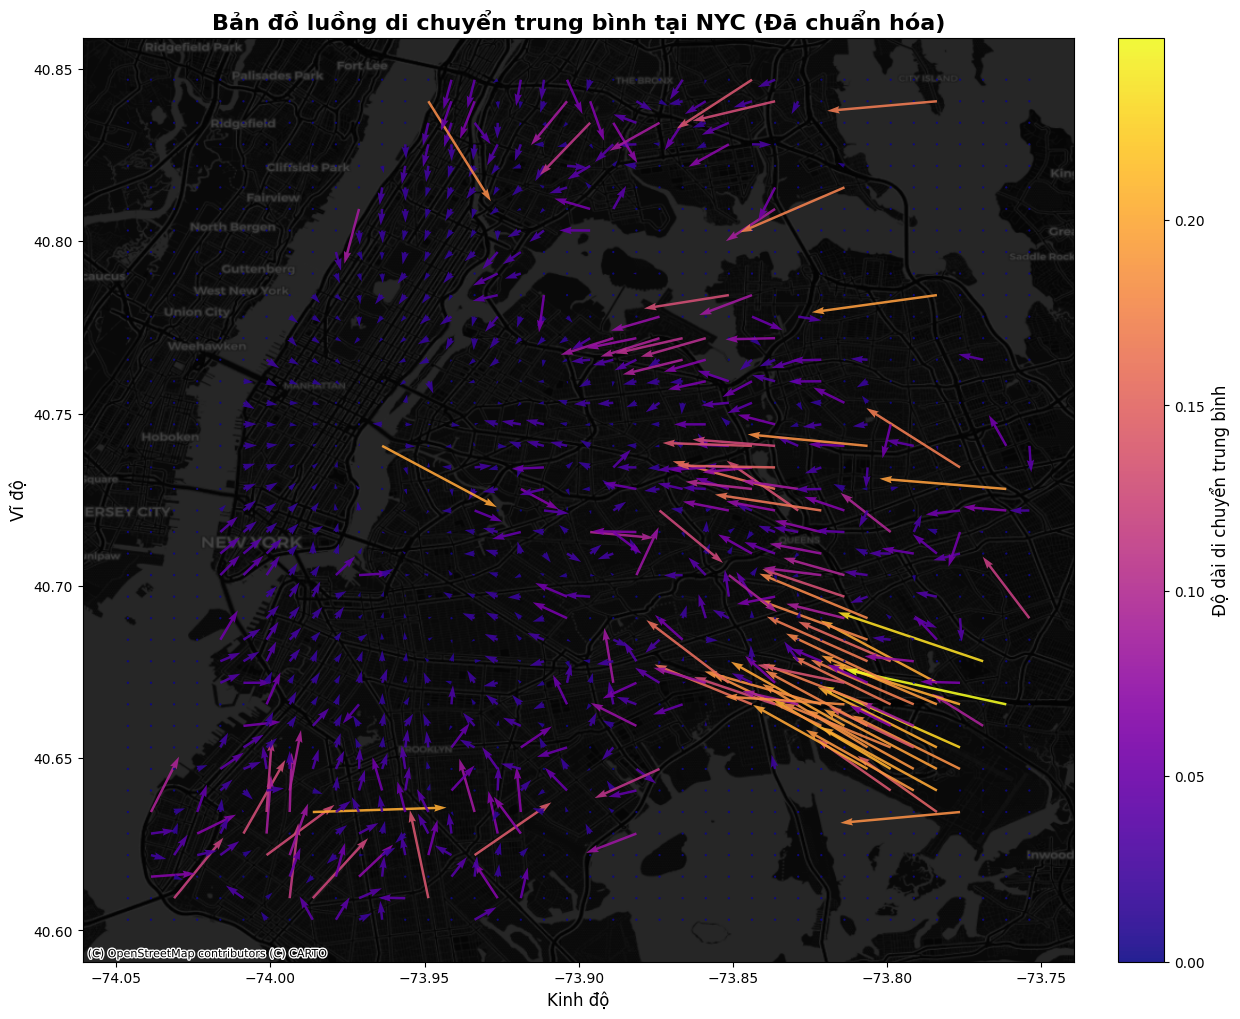

In [58]:
# 1. Chuẩn bị dữ liệu: Tính toán chênh lệch tọa độ (Vector di chuyển)
df_clean['dx'] = df_clean['dropoff_longitude'] - df_clean['pickup_longitude']
df_clean['dy'] = df_clean['dropoff_latitude'] - df_clean['pickup_latitude']

# 2. Chia lưới (Grid) 40x40 ô để gom nhóm dữ liệu
lon_bins = np.linspace(-74.05, -73.75, 41)
lat_bins = np.linspace(40.60, 40.85, 41)

# Tính giá trị trung bình của vector dx, dy trong từng ô lưới
idx_lon = np.digitize(df_clean['pickup_longitude'], lon_bins) - 1
idx_lat = np.digitize(df_clean['pickup_latitude'], lat_bins) - 1

# Tạo mảng chứa vector trung bình
grid_u = np.zeros((40, 40))
grid_v = np.zeros((40, 40))

for i in range(40):
    for j in range(40):
        mask = (idx_lon == i) & (idx_lat == j)
        if mask.any():
            grid_u[j, i] = df_clean.loc[mask, 'dx'].mean()
            grid_v[j, i] = df_clean.loc[mask, 'dy'].mean()

# 3. Vẽ biểu đồ Quiver (Mũi tên)
ig, ax = plt.subplots(figsize=(14, 12))

lon_mid = (lon_bins[:-1] + lon_bins[1:]) / 2
lat_mid = (lat_bins[:-1] + lat_bins[1:]) / 2
lon_grid, lat_grid = np.meshgrid(lon_mid, lat_mid)

# 1. TÍNH TOÁN ĐỘ LỚN CỦA VECTOR (Magnitude)
# Dùng định lý Pytago: c = căn bậc 2 của (a^2 + b^2)
magnitude = np.sqrt(grid_u**2 + grid_v**2)

# 2. VẼ MŨI TÊN VỚI MÀU SẮC DỰA TRÊN ĐỘ LỚN
# - Truyền 'magnitude' vào làm tham số thứ 5 để map màu.
# - scale=1.5 (Tăng số này lên để mũi tên NGẮN lại, tránh chồng lấp)
# - cmap='plasma': Thang màu cực đẹp cho nền tối (Tím -> Đỏ -> Vàng sáng)
q = ax.quiver(lon_grid, lat_grid, grid_u, grid_v, magnitude, 
              cmap='plasma', scale=1.5, width=0.0025, alpha=0.9)

# 3. THÊM THANH CHÚ THÍCH MÀU (Colorbar)
cbar = plt.colorbar(q, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Độ dài di chuyển trung bình', fontsize=12)

# 4. THÊM BẢN ĐỒ NỀN
ctx.add_basemap(ax, crs="EPSG:4326", source=ctx.providers.CartoDB.DarkMatter)

ax.set_title('Bản đồ luồng di chuyển trung bình tại NYC (Đã chuẩn hóa)', fontsize=16, fontweight='bold')
ax.set_xlabel('Kinh độ', fontsize=12)
ax.set_ylabel('Vĩ độ', fontsize=12)

plt.show()

Bản đồ Vector cho thấy giao thông Taxi New York phân hóa thành 2 thái cực rõ rệt: Các chuyến đi nội khu Manhattan thường ngắn, chậm và đa hướng; trong khi các chuyến ra ngoại ô/sân bay mang tính định hướng cao, quãng đường dài. Phát hiện này là cơ sở quan trọng để nhóm quyết định phải đưa tọa độ GPS (latitude/longitude) vào làm 'đặc trưng' (feature) bắt buộc khi huấn luyện mô hình dự đoán thời gian.

C:\Users\hjiis\AppData\Local\Temp\ipykernel_496\476160599.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='pickup_hour', y='trip_duration', data=df_clean,


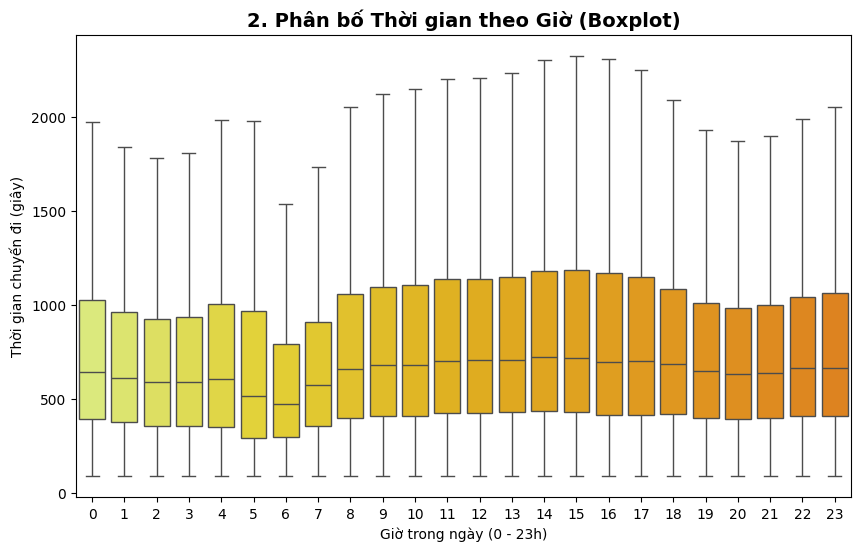

In [59]:
plt.figure(figsize=(10, 6)) # Chiều ngang dài hơn một chút để chứa đủ 24 giờ

# showfliers=False giúp ẩn đi các điểm nhiễu (outliers) để thấy rõ hình dáng chiếc hộp
sns.boxplot(x='pickup_hour', y='trip_duration', data=df_clean, 
            palette='Wistia', showfliers=False)

plt.title('2. Phân bố Thời gian theo Giờ (Boxplot)', fontsize=14, fontweight='bold')
plt.xlabel('Giờ trong ngày (0 - 23h)')
plt.ylabel('Thời gian chuyến đi (giây)')

# Giới hạn trục Y để dễ quan sát sự chênh lệch của các hộp
plt.show()

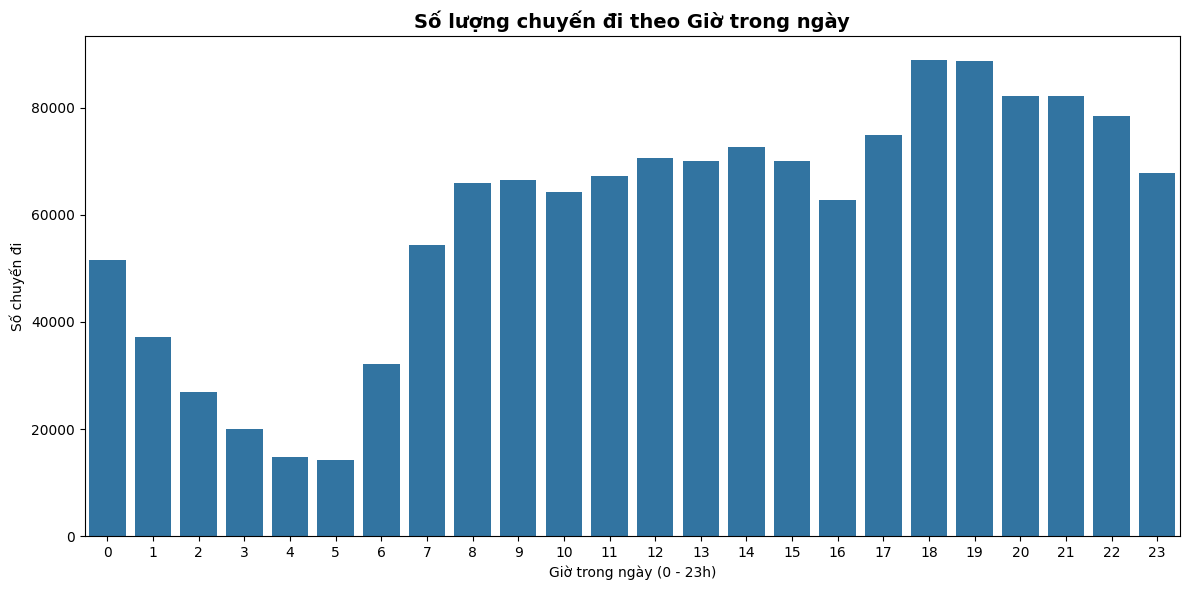

In [60]:
plt.figure(figsize=(12, 6)) # Chiều ngang dài hơn một chút để chứa đủ 24 giờ

sns.countplot(x='pickup_hour', data=df_clean)

plt.title('Số lượng chuyến đi theo Giờ trong ngày', fontsize=14, fontweight='bold')
plt.xlabel('Giờ trong ngày (0 - 23h)')
plt.ylabel('Số chuyến đi')

plt.xticks(ticks=range(0, 24), labels=range(0, 24))
plt.tight_layout()
plt.show()

1. Hiệu ứng "Cuốc xe đường dài" (Long-haul Bias)
Lúc 4h - 5h sáng, những người đi chơi đêm ở trung tâm Manhattan (quãng đường ngắn) đã về nhà hết. Ai là những người phải gọi taxi vào giờ này?

Hành khách ra sân bay sớm: Những người có chuyến bay lúc 6h-7h sáng ở JFK hoặc LaGuardia.

Người đi làm ca sớm: Công nhân hoặc nhân viên ở các khu vực ngoại vi đi vào thành phố.
Những cuốc xe này có quãng đường (distance) dài hơn hẳn mức trung bình, nên thời gian di chuyển (duration) chắc chắn sẽ bị kéo dài ra, khiến trung vị và chiều cao của hộp Boxplot bị đẩy lên cao. Tức là họ đi nhanh (tốc độ cao) nhưng vì đi quá xa nên tổng thời gian vẫn lớn!

2. Tốc độ cao làm tăng Phương sai (Variance)
Hãy nhìn vào râu trên (upper whisker) của hộp lúc 4h và 5h sáng, nó kéo lên rất cao (gần 2000 giây).
Vì đường lúc này cực kỳ vắng, các tài xế chạy trên cao tốc ra sân bay có thể vít ga với tốc độ tối đa, hoàn thành chuyến đi 30km chỉ trong 15-20 phút. Sự chênh lệch giữa một cuốc xe ngắn vài block nhà và một cuốc chạy ra sân bay lúc đường vắng tạo ra một sự phân tán dữ liệu lớn, kéo giãn chiều cao của cái hộp ra.

Để giải thích nghịch lý lúc 4h sáng, nhóm có thể vẽ thêm một biểu đồ phụ: Khoảng cách di chuyển trung bình theo giờ. Nhóm dự đoán rằng khoảng cách trung bình lúc 4h-5h sáng sẽ là cao nhất trong ngày (do tỷ trọng khách ra sân bay cao), giải thích hoàn hảo cho việc tại sao thời gian chuyến đi lại nhô lên dù lượng xe là ít nhất.

C:\Users\hjiis\AppData\Local\Temp\ipykernel_496\801729488.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='pickup_hour', y='dist_manhattan_km', data=df_clean,


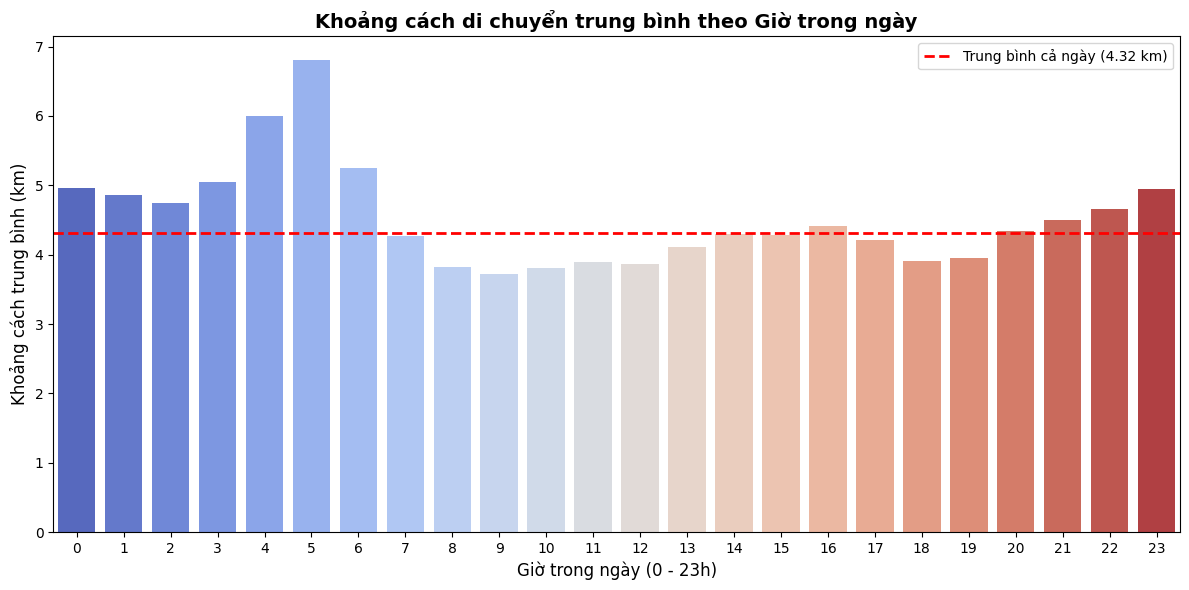

In [61]:
# Khởi tạo khung hình
plt.figure(figsize=(12, 6))

# Vẽ biểu đồ cột: Chiều cao cột thể hiện Khoảng cách Trung bình (mean)
# estimator=np.mean: Tự động tính trung bình khoảng cách cho từng giờ
# errorbar=None: Tắt các vạch đen (độ lệch chuẩn) cho biểu đồ gọn gàng
sns.barplot(x='pickup_hour', y='dist_manhattan_km', data=df_clean, 
            estimator=np.mean, errorbar=None, palette='coolwarm')

plt.title('Khoảng cách di chuyển trung bình theo Giờ trong ngày', fontsize=14, fontweight='bold')
plt.xlabel('Giờ trong ngày (0 - 23h)', fontsize=12)
plt.ylabel('Khoảng cách trung bình (km)', fontsize=12)

# Hiển thị đủ 24 số trên trục X
plt.xticks(ticks=range(0, 24), labels=range(0, 24))

# TÙY CHỌN NÂNG CAO: Vẽ thêm 1 đường gạch ngang màu đỏ đứt nét 
# thể hiện mức trung bình của toàn bộ cả ngày để làm mốc so sánh
mean_distance = df_clean['dist_manhattan_km'].mean()
plt.axhline(mean_distance, color='red', linestyle='--', linewidth=2, 
            label=f'Trung bình cả ngày ({mean_distance:.2f} km)')
plt.legend()

plt.tight_layout()
plt.show()

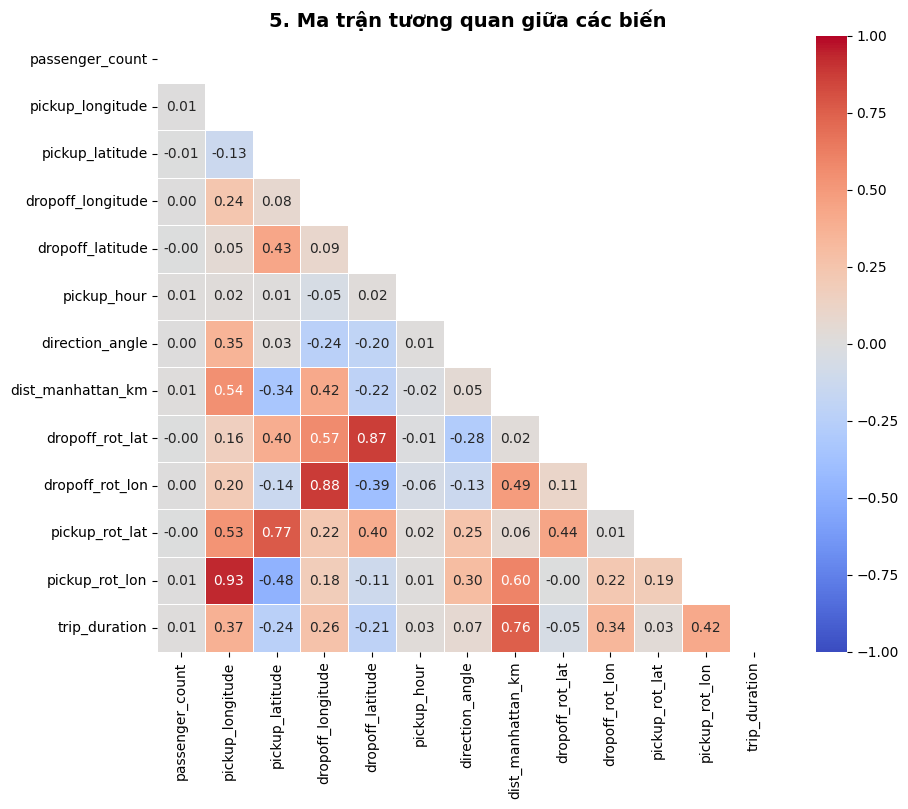

In [62]:
# --- Biểu đồ 5: Ma trận Tương quan (Heatmap) ---
plt.figure(figsize=(10, 8))

cols_to_corr = ['passenger_count', 'pickup_longitude', 'pickup_latitude', 
                'dropoff_longitude', 'dropoff_latitude','pickup_hour',
                'direction_angle','dist_manhattan_km','dropoff_rot_lat','dropoff_rot_lon', "pickup_rot_lat", "pickup_rot_lon",
                'trip_duration']
corr_matrix = df_clean[cols_to_corr].corr()

# Tạo mask để ẩn nửa trên của ma trận (vì nó đối xứng)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', 
            vmin=-1, vmax=1, square=False, linewidths=.5)

plt.title('5. Ma trận tương quan giữa các biến', fontsize=14, fontweight='bold')

plt.show()

Hãy nhìn vào hàng trip_duration. Nó có tương quan rõ nét nhất với 4 biến tọa độ:

pickup_longitude (0.37) và dropoff_longitude (0.26): Tương quan dương (Màu cam). Kinh độ càng tăng (càng đi dịch về phía Đông như Queens, Brooklyn) thì thời gian chuyến đi càng dài.

pickup_latitude (-0.24) và dropoff_latitude (-0.21): Tương quan âm (Màu xanh lam). Vĩ độ càng tăng (càng đi ngược lên phía Bắc như Bronx) thì thời gian lại có xu hướng giảm.

Ý nghĩa: Tọa độ địa lý có ảnh hưởng tuyến tính rõ ràng đến thời gian chạy của xe taxi. Điều này tái khẳng định phát hiện của nhóm ở bản đồ Vector trước đó: Luồng giao thông và kẹt xe phân bổ không đồng đều trên bản đồ New York.

Ý nghĩa kinh doanh & Kỹ thuật: Việc xe chở 1 người hay 6 người (xe 7 chỗ) hoàn toàn KHÔNG ảnh hưởng đến việc xe chạy nhanh hay chậm. Kẹt xe không phân biệt xe chở mấy người!

Dù hệ số tương quan của pickup_hour rất thấp, nhưng qua các biểu đồ phân phối trước đó, nhóm biết chắc chắn nó có ảnh hưởng mạnh. Điều này chứng tỏ chúng ta không thể dùng các mô hình hồi quy tuyến tính (Linear Regression) đơn giản, mà bắt buộc phải dùng các thuật toán dạng cây (Tree-based) như XGBoost để xử lý các quan hệ phi tuyến tính phức tạp của giao thông đô thị.

TỔNG HỢP CÁC PHÁT HIỆN CHÍNH (KEY FINDINGS):

Giờ cao điểm và quy luật nhu cầu: Nhu cầu taxi tăng mạnh từ cuối giờ chiều (18h-19h) và duy trì cao vào buổi tối. Đây là khung giờ cần tập trung phân bổ lượng xe lớn nhất để tối ưu doanh thu.
Đặc thù khu vực hoạt động: Giao thông tập trung cực kỳ đậm đặc tại khu trung tâm (Manhattan). Các chuyến đi nội đô thường ngắn và chậm, trong khi các chuyến đi ra ngoại ô có xu hướng định hướng rõ ràng và quãng đường dài hơn.
Sự ổn định về cấu trúc chuyến đi: Phần lớn khách hàng đi taxi một mình (1 người), chiếm tỷ trọng áp đảo. Việc hiểu rõ quy mô nhóm khách hàng giúp hãng taxi có thể tối ưu hóa các loại dòng xe vận hành để tiết kiệm chi phí nhiên liệu.